In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/pdf_v3/Fig 1"

inc_density = pd.read_csv('PolygonIncDensity.csv')
inc_density

,num_sides_polygon,spacing(mm),diameter(mm),force_mag(N),nonlinearity,memory,nonlinearity_cap,memory_cap
0,6,125.000000,500.0,0.025600,0.345064,0.095566,0.440929,0.103176
1,8,176.776695,500.0,0.009051,0.291080,0.095216,0.320827,0.103337
2,10,202.254249,500.0,0.006043,0.279000,0.095594,0.299450,0.104959
3,12,216.506351,500.0,0.004927,0.253627,0.094691,0.343231,0.110983


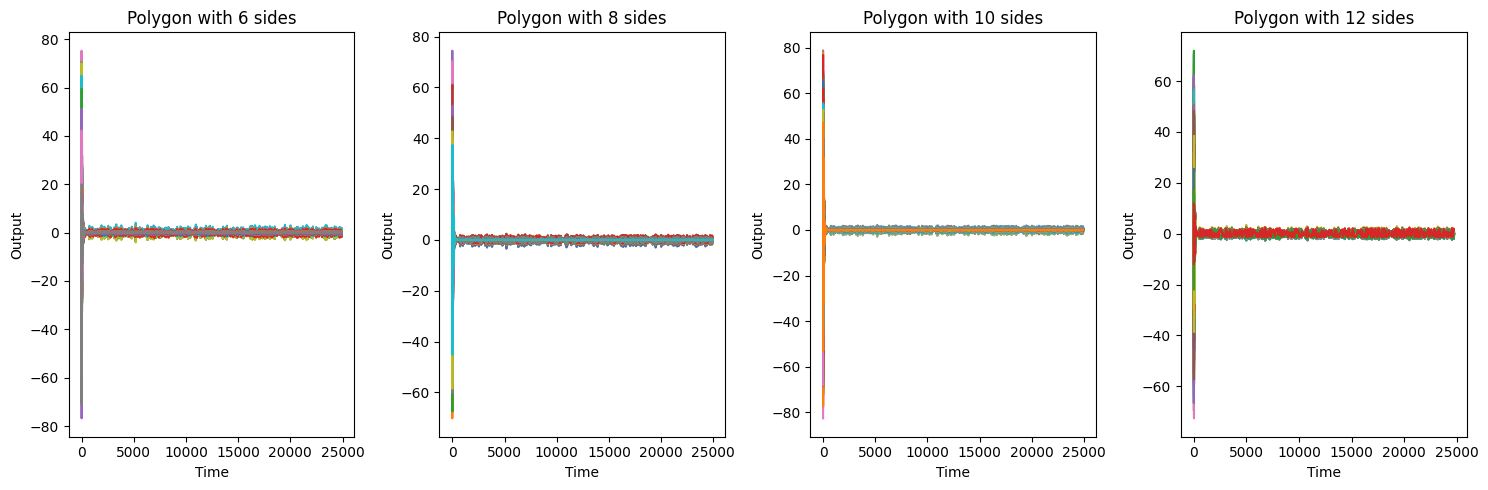

In [2]:
num_sides_polygon = inc_density['num_sides_polygon'].values.tolist()

fig, ax = plt.subplots(1, len(num_sides_polygon), figsize=(15, 5))
for i in range(len(num_sides_polygon)):
    data = np.load(f'{i}_eval_trans.npz', allow_pickle=True)
    output_data = data['output_data']
    ax[i].plot(output_data)
    # ax[i].set_xlim(0, 250)
    # ax[i].set_ylim(-10, 10)
    ax[i].set_title(f'Polygon with {num_sides_polygon[i]} sides')
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Output')

plt.tight_layout()
plt.show() 


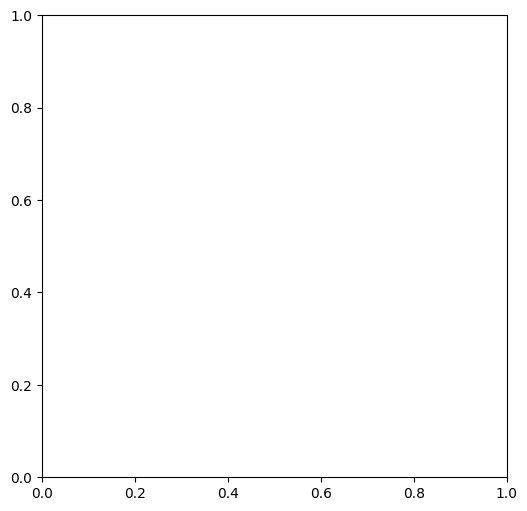

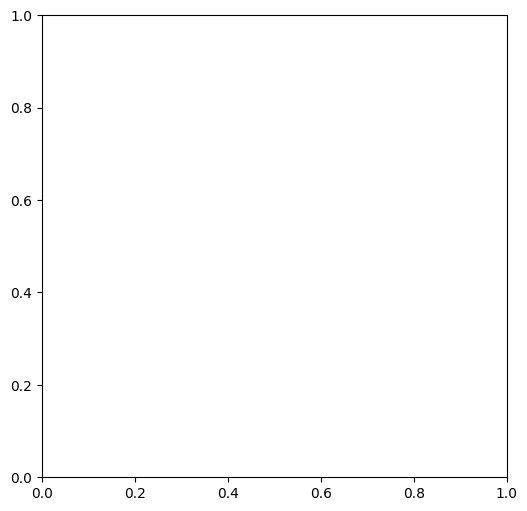

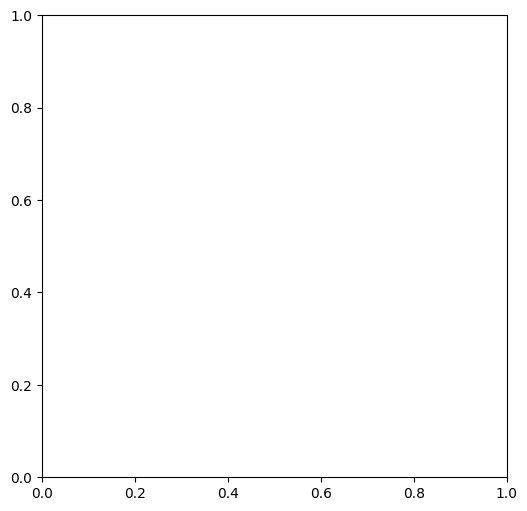

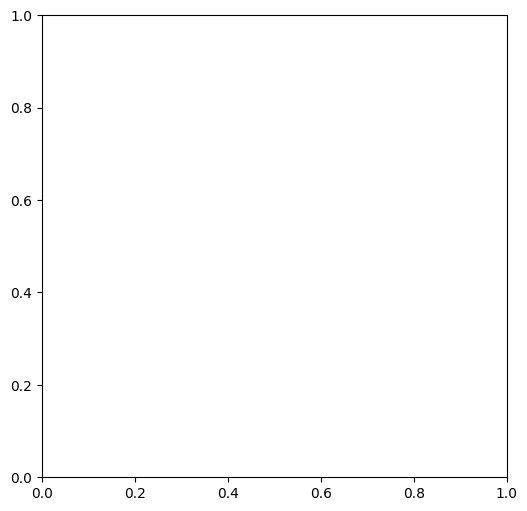

In [2]:
matplotlib.rc('pdf', fonttype=42)
num_sides_polygon = inc_density['num_sides_polygon'].values.tolist()

leg_x = np.linspace(1, 10, 10)
mem_x = np.linspace(0, 1, 251)

fig1, ax1 = plt.subplots(1, 1, figsize=(6, 6))
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
fig3, ax3 = plt.subplots(1, 1, figsize=(6, 6))
fig4, ax4 = plt.subplots(1, 1, figsize=(6, 6))
axs = [ax1, ax2, ax3, ax4]

onc_list = []
omc_list = []

for i in range(len(num_sides_polygon)):
    data = np.load(f'{i}_eval_trans.npz', allow_pickle=True)
    # axs[0].plot(leg_x, data['nonlinearity'][0], '-o', label=f'{num_sides_polygon[i]} sides')
    # axs[1].plot(leg_x, data['nonlinearity'][1], '-o', label=f'{num_sides_polygon[i]} sides')
    # axs[2].plot(mem_x, data['memory'][0], '-o', label=f'{num_sides_polygon[i]} sides')
    # axs[3].plot(mem_x, data['memory'][1], '-o', label=f'{num_sides_polygon[i]} sides')

    onc_list.append(sum(data['nonlinearity'][1])/len(data['nonlinearity'][1]))
    omc_list.append(sum(data['memory'][1])/len(data['memory'][1]))
    inc_density.at[i, 'nonlinearity_cap'] = onc_list[-1]
    inc_density.at[i, 'memory_cap'] = omc_list[-1]

inc_density.to_csv('PolygonIncDensity.csv', index=False)

# for ax in axs:
#     ax.legend(loc='upper right')
#     ax.set_ylabel('Capacity')
#     ax.set_ylim(-0.1, 1.1)
# axs[0].set_title('Nonlinearity Capacity')
# axs[1].set_title('Nonlinearity Capacity')
# axs[2].set_title('Memory Capacity')
# axs[3].set_title('Memory Capacity')
# axs[0].set_xlabel('Legendre Polynomial Order')
# axs[1].set_xlabel('Legendre Polynomial Order')
# axs[2].set_xlabel('Time (s)')
# axs[3].set_xlabel('Time (s)')

# # plt.show()

# fig1.savefig(f'{path}/Increasing_Density_Polygon_Nonlinearity_Training.pdf', dpi=300)
# fig2.savefig(f'{path}/Increasing_Density_Polygon_Nonlinearity_Testing.pdf', dpi=300)
# fig3.savefig(f'{path}/Increasing_Density_Polygon_Memory_Training.pdf', dpi=300)
# fig4.savefig(f'{path}/Increasing_Density_Polygon_Memory_Testing.pdf', dpi=300)

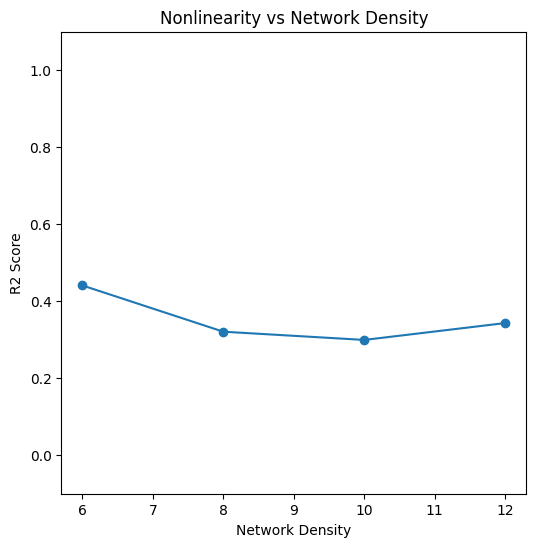

In [4]:
fig5, ax5 = plt.subplots(1, 1, figsize=(6, 6))
ax5.plot(num_sides_polygon, onc_list, '-o')
ax5.set_xlabel('Network Density')
ax5.set_ylabel('R2 Score')
ax5.set_title('Nonlinearity vs Network Density')
ax5.set_ylim(-0.1, 1.1)
fig5.savefig(f'{path}/Increasing_Density_Polygon_Nonlinearity_vs_Density.pdf', dpi=300)


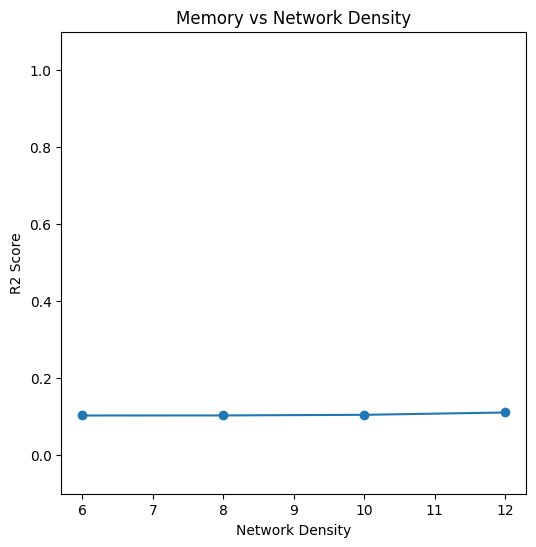

In [5]:
fig6, ax6 = plt.subplots(1, 1, figsize=(6, 6))
ax6.plot(num_sides_polygon, omc_list, '-o')
ax6.set_xlabel('Network Density')
ax6.set_ylabel('R2 Score')
ax6.set_title('Memory vs Network Density')
ax6.set_ylim(-0.1, 1.1)
fig6.savefig(f'{path}/Increasing_Density_Polygon_Memory_vs_Density.pdf', dpi=300)